## White Wine Project 

#### How to use this notebook
This notebook contains the analysis of white wine quality. The purpose is to determine what factors influence the quality of white wine.

To use, open this notebook and run the cells from top to bottom and ensure files are in the same folder. The dataset used is sourced from Wine Rating & Price from Kaggle and it is stored in this repository under project.

The files included in this project are White.csv, raw_white_wine.csv,  cleaned_white_wine.csv and results_white_wine.csv.

No external API is required for this notebook.

The libraries needed for this notebook are pandas, numpy, matplotlib and seaborn.

##### Visual Data Pipeline

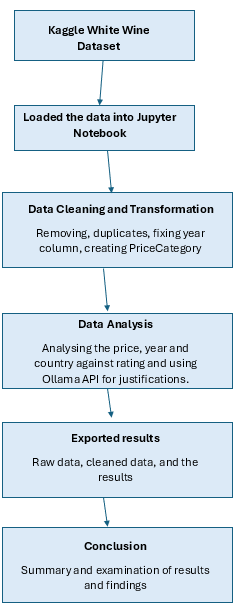

#### Statement of AI
AI was used in this project for troubleshooting where I couldn't immediately find the issue. I also used it to generate a list of statistical tests for signifcance I could use before further researching them and deciding on the best one.

#### Introduction
This project aims to analyse the various characteristics of white wines to determine which features contribute to a high-quality wine. If it can be determined what factors influence the quality of wine and to what degree, a predictive model could be created to predict the quality of a wine before purchase helping consumers to make more informed decisions.

The dataset was compiled by Anton Budnyak and was originally presented on Vivino.com. It was updated 6 years ago. There are 3,764 different white wines in the data set.

The analysis will focus on the following factors: country, price and year of production. Wine ratings will be used as the primary measure of quality to evaluate what makes a good white wine. 

#### Loading the dataset

In [118]:
import pandas as pd
import numpy as np

df_wine = pd.read_csv("White.csv")

df_wine.head()

,Name,Country,Region,Winery,Rating,NumberOfRatings,Price,Year
0,Vermentino 2017,Italy,Toscana,Famiglia Castellani,3.8,25,5.65,2017
1,Ronco Broilo 2010,Italy,Colli Orientali del Friuli,Conte d'Attimis Maniago,4.3,25,44.90,2010
2,Weisser Schiefer s 2017,Austria,Südburgenland,Weinbau Uwe Schiefer,4.2,25,33.25,2017
3,Chardonnay 2018,Germany,Rheinhessen,Krämer - Straight,3.9,25,8.99,2018
4,Maganza Zibibbo 2018,Italy,Terre Siciliane,Luna Gaia,3.9,25,8.60,2018


#### Exporting the raw dataset

In [119]:
df_wine.to_csv("raw_white_wine.csv", index = False)

# To load this raw dataset uncomment the line below
# df_wine = pd.read_csv("raw_white_wine.csv")

#### Cleaning and transforming the data

##### Inspecting the dataset

In [120]:
df_wine.info()

df_wine.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3764 entries, 0 to 3763
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             3764 non-null   object 
 1   Country          3764 non-null   object 
 2   Region           3764 non-null   object 
 3   Winery           3764 non-null   object 
 4   Rating           3764 non-null   float64
 5   NumberOfRatings  3764 non-null   int64  
 6   Price            3764 non-null   float64
 7   Year             3764 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 235.4+ KB


,Rating,NumberOfRatings,Price
count,3764.000000,3764.000000,3764.000000
mean,3.817906,187.567216,20.620319
std,0.266827,1071.470441,30.928415
min,2.200000,25.000000,3.740000
25%,3.600000,43.000000,9.260000
50%,3.800000,77.000000,13.150000
75%,4.000000,174.250000,20.865000
max,4.900000,62980.000000,681.370000


From this we can see that there are no missing values, but now we need to check that there are no placeholder values for each column.

##### Checking for duplicates

In [121]:
# Checking each column for the placeholder values 
print(df_wine["Name"].value_counts())
print(df_wine["Country"].value_counts())
print(df_wine["Region"].value_counts())
print(df_wine["Winery"].value_counts())
print(df_wine["Rating"].value_counts())
print(df_wine["NumberOfRatings"].value_counts())
print(df_wine["Price"].value_counts())
print(df_wine["Year"].value_counts())

Name
Chardonnay 2018                                 78
Sauvignon Blanc 2019                            66
Sauvignon Blanc 2018                            51
Chardonnay 2017                                 41
Riesling Trocken 2018                           27
                                                ..
Inzolia - Chardonnay 2018                        1
Gorges 2015                                      1
Juffer Riesling Trocken GG 2018                  1
Zeltinger Sonnenuhr Riesling Auslese*** 2003     1
Vinho Verde Branco N.V.                          1
Name: count, Length: 3040, dtype: int64
Country
Germany           888
Italy             792
France            653
South Africa      296
Spain             256
Austria           243
United States     135
Chile              99
New Zealand        94
Portugal           89
Australia          67
Argentina          56
Romania            12
Switzerland        11
Greece             10
Hungary            10
Slovenia            9
Israel      

From this we can see that the dataset contained no missing values or placeholder entries. All columns contain complete and valid entries. All prices are above 0 and there are no impossible years or negative values where that would not be feasible.

In [122]:
df_wine.duplicated().sum()

np.int64(0)

From this we can see that there are no duplicate rows.

In [123]:
# Changing Year data type from object to float type
df_wine['Year'] = pd.to_numeric(df_wine['Year'], errors='coerce')

# Checking it worked

print(df_wine.dtypes["Year"])


float64


For this project, the number of ratings is not relevant as we are just looking at the overall rating the wine recived so we will drop the number of ratings column.    

In [124]:
df_wine.drop(columns=["NumberOfRatings"], inplace=True)

# Check this dropped the column
df_wine.columns

Index(['Name', 'Country', 'Region', 'Winery', 'Rating', 'Price', 'Year'], dtype='object')

As the prices vary from €3.74 to €861.37 so to make the analysis comparing cheaper and expensive wines easier to understaned, they will be grouped into bins.

In [125]:
df_wine["PriceCategory"] = pd.cut(
    df_wine["Price"],
    bins = [0, 10, 20, 50, 100, 500],
    labels = ["Budget", "Economy", "Mid", "Premium", "Luxury"]
)

# Checking the code works
df_wine[["Price", "PriceCategory"]].head(6)

,Price,PriceCategory
0,5.65,Budget
1,44.90,Mid
2,33.25,Mid
3,8.99,Budget
4,8.60,Budget
5,15.90,Economy


The data has now been cleaned and transformed and is ready for analysis, to export the cleaned data file see below.

In [126]:
df_wine.to_csv("cleaned_white_wine.csv", index = False)

# To load this cleaned dataset uncomment the line below
# df_wine = pd.read_csv("cleaned_white_wine.csv")

#### Analysis of Data

We have 5 main characteristics of the wine: price, year, country, region, winery. For this analysis we will focus on just price, year and country. Country has been chosen over region and winery as it has a larger sample sizes within the countries. Region and winery have many low frequency categories with many regions or wineries appearing only once or twice making comparison more difficult. First we will explore the relation between price and rating.

##### Price and Rating
Price refers to the price the wine is being sold for in euros.

PriceCategory
Budget     3.639286
Economy    3.807784
Mid        4.004980
Premium    4.186986
Luxury     4.403704
Name: Rating, dtype: float64


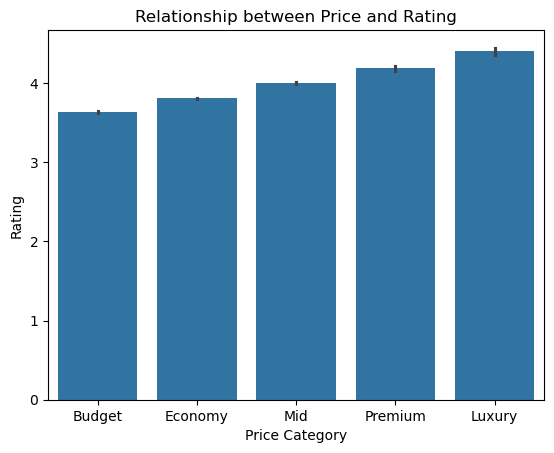

In [140]:
# First we are looking at the mean rating for each price category and then plotting it on a bar chart.

import seaborn as sns
import matplotlib.pyplot as plt

print(df_wine.groupby("PriceCategory", observed=True)["Rating"].mean())

sns.barplot(x="PriceCategory", y="Rating", data=df_wine)
plt.xlabel('Price Category')
plt.title('Relationship between Price and Rating')
plt.show()


Now we have seen that the rating goes up in each price category. Now we need to look at the distribution within these categories and how many results are in each category.

In [128]:
# How many wines in each category
df_wine["PriceCategory"].value_counts()

PriceCategory
Economy    1593
Budget     1204
Mid         763
Premium     146
Luxury       54
Name: count, dtype: int64

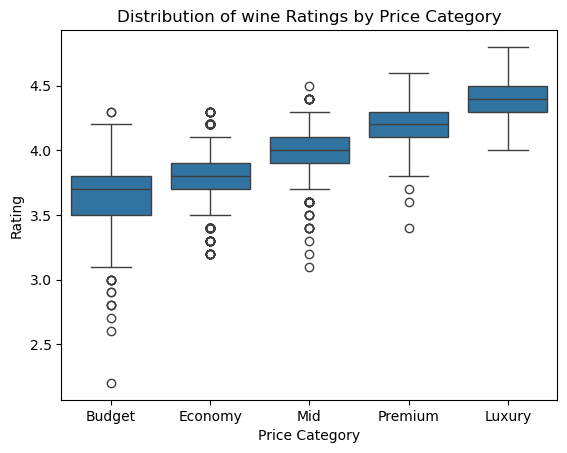

In [129]:
sns.boxplot(x="PriceCategory", y ="Rating", data=df_wine)
plt.xlabel('Price Category')
plt.title('Distribution of wine Ratings by Price Category')
plt.show()

From above, it can be seen that budget has a much larger sample size than luxury, however, as luxury sample size is 54, it is still sufficient for analysis. In terms of distribution, budget and mid price categories have the greatest variability and budget having the most extreme outliers, one below 2.5, suggesting that they have a higher risk of disappointment. Luxury and premium wines provide a higher quality more consistently. However to we need to discover if these results are significant.

In [130]:
# Testing to see if results are significant
from scipy.stats import f_oneway

# Hypothesis
# H0: There is no significant difference in the mean wine ratings between the different price categories.
# H1: There is significant difference in mean wine ratings between at least one of the price categories. 

# Group the ratings by category
Budget = df_wine[df_wine["PriceCategory"] == "Budget"]["Rating"]
Economy = df_wine[df_wine["PriceCategory"] == "Economy"]["Rating"]
Mid = df_wine[df_wine["PriceCategory"] == "Mid"]["Rating"]
Premium = df_wine[df_wine["PriceCategory"] == "Premium"]["Rating"]
Luxury = df_wine[df_wine["PriceCategory"] == "Luxury"]["Rating"]

f_statistic, p_value = f_oneway(Budget, Economy, Mid, Premium, Luxury)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")


F-statistic: 601.5585008264425
P-value: 0.0


A one-way ANOVA is used to check if there are significant differences between the means of three or more groups. The p statistic is below 0.05 which means that we reject the null hypothesis and there is statistical significance. There is a significant difference in mean wine ratings between at least one of the price categories, however, we don't know which one.

The higher the price of white wine, the higher the average rating, and this result has been proven to be significant. This means that a more expensive wine will likely be higher quality and the higher the quality the more stable the results are.

##### Year and Rating
Year refers to the year the wine was produced.

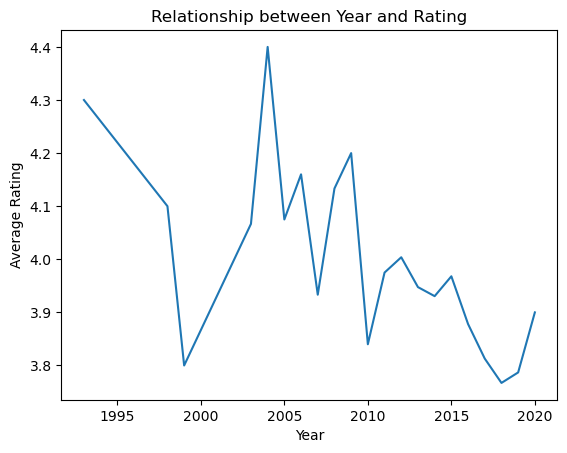

In [131]:
# First we are looking at the mean rating per year and a line plot of this.

# Calculating mean
year_avg = (df_wine.groupby("Year", observed=True)["Rating"].mean().reset_index())

sns.lineplot(x="Year", y="Rating", data=year_avg)
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Relationship between Year and Rating')
plt.show()

In [132]:
# How many wines in each category
year_counts = df_wine["Year"].value_counts()
print(year_counts)

Year
2018.0    1440
2017.0     787
2019.0     588
2016.0     484
2015.0     250
2014.0      85
2013.0      42
2012.0      26
2011.0      24
2010.0       5
2006.0       5
2005.0       4
2007.0       3
2003.0       3
2008.0       3
1999.0       2
2004.0       2
2020.0       2
2009.0       2
1998.0       1
1993.0       1
Name: count, dtype: int64


A lineplot was chosen as it is good for showing relationships over time such as how rating varies with year. From the lineplot we can see no consistent pattern and many spikes, so when looking at how many wines were produced in each year in the dataset we can see that more recent years have a much higher sample size, whereas years before 2010 have much lower frequency causing the spikes in the graph. However the ratings are quite consistent only varying between 3.8 and 4.4. Below the data is filtered for years with more than 30 samples to see how this affects the graph.

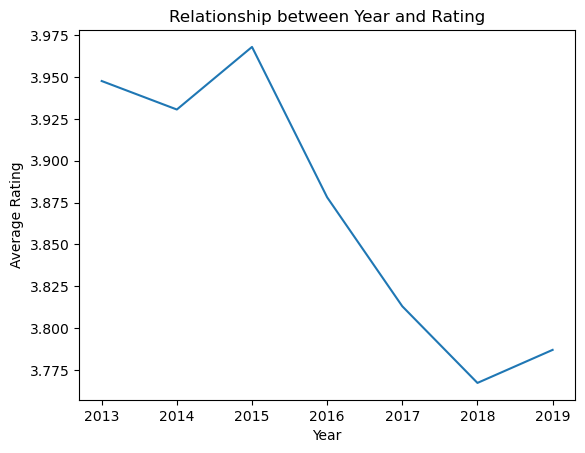

In [133]:
valid_years = year_counts[year_counts >= 30].index
df_filtered = df_wine[df_wine["Year"].isin(valid_years)]

year_avg_filtered = (df_filtered.groupby("Year", observed=True)["Rating"].mean().reset_index())

sns.lineplot(x="Year", y="Rating", data=year_avg_filtered)
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Relationship between Year and Rating')
plt.show()


From this we can see that average wine ratings appear to decrease when wine is produced more recently apart from a peak in 2015, however the differnce between lowest rated year, 2018, and highest rated year, 2015, is only 0.025.

Therefore, we can conclude there is no obvious correlation between average wine rating and year it was produced. The unequal sample size across the years may be a reason no pattern can be seen.

##### Country and Rating
Country refer to the country of origin.

In [134]:
# First we will check how samples size for each country 
country_counts = df_wine["Country"].value_counts()

As we can see there are many countries with small sample size, some with only 1. So to make analysis more meaningful we will filter for sample sizes over 30 before we continue the analysis.

          Country    Rating
0       Argentina  3.762500
1       Australia  3.595522
2         Austria  3.825514
3           Chile  3.580808
4          France  3.881317
5         Germany  3.895495
6           Italy  3.797601
7     New Zealand  3.903191
8        Portugal  3.811236
9    South Africa  3.725676
10          Spain  3.759375
11  United States  3.742963


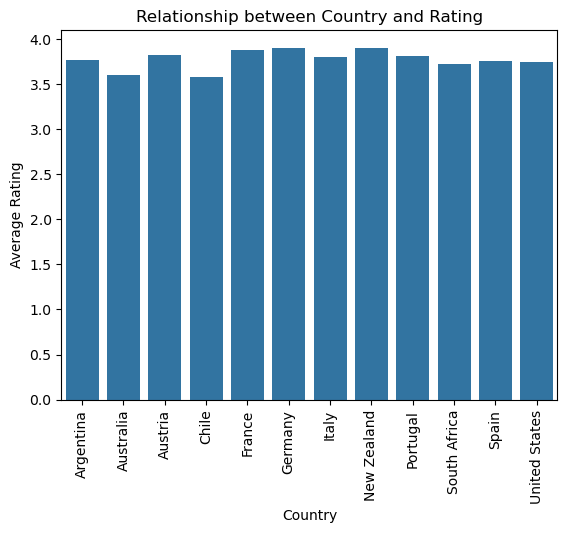

In [135]:
# Filtering out for sample size over 30

valid_country = country_counts[country_counts >= 30].index
df_filtered_country = df_wine[df_wine["Country"].isin(valid_country)]

country_avg_filtered = (df_filtered_country.groupby("Country", observed=True)["Rating"].mean().reset_index())

print(country_avg_filtered)

sns.barplot(x="Country", y="Rating", data=country_avg_filtered)
plt.xlabel('Country')
plt.ylabel('Average Rating')
plt.title('Relationship between Country and Rating')
plt.xticks(rotation=90)
plt.show()

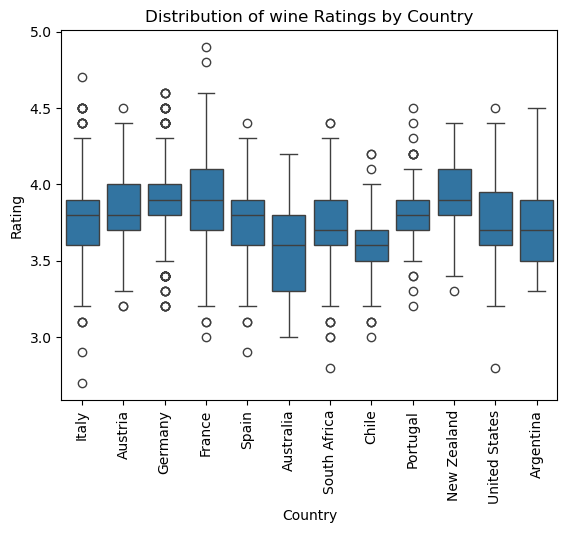

In [136]:
# Looking at the distribution
sns.boxplot(x="Country", y ="Rating", data=df_filtered_country)
plt.xlabel('Country')
plt.title('Distribution of wine Ratings by Country')
plt.xticks(rotation=90)
plt.show()

As we can see there are differences in the mean average rating as well as the distribution of ratings in each country, Germany and Chile have ratings more closely whereas Australia has more spread distribution. To see if the differences in mean are significant, we shall carry out an ANOVA test like we did for price.

In [137]:
# Hypothesis
# H0: There is no significant difference in the mean wine ratings between the different countries.
# H1: There is significant difference in mean wine ratings between at least one of the countries. 

# Group the ratings by category
Argentina = df_filtered_country[df_filtered_country["Country"] == "Argentina"]["Rating"]
Australia = df_filtered_country[df_filtered_country["Country"] == "Australia"]["Rating"]
Austria = df_filtered_country[df_filtered_country["Country"] == "Austria"]["Rating"]
Chile = df_filtered_country[df_filtered_country["Country"] == "Chile"]["Rating"]
France = df_filtered_country[df_filtered_country["Country"] == "France"]["Rating"]
Germany = df_filtered_country[df_filtered_country["Country"] == "Germany"]["Rating"]
Italy = df_filtered_country[df_filtered_country["Country"] == "Italy"]["Rating"]
NewZealand = df_filtered_country[df_filtered_country["Country"] == "New Zealand"]["Rating"]
Portugal = df_filtered_country[df_filtered_country["Country"] == "Portugal"]["Rating"]
SouthAfrica = df_filtered_country[df_filtered_country["Country"] == "South Africa"]["Rating"]
Spain = df_filtered_country[df_filtered_country["Country"] == "Spain"]["Rating"]
UnitedStates = df_filtered_country[df_filtered_country["Country"] == "United States"]["Rating"]


f_statistic, p_value = f_oneway(Argentina, Australia, Austria, Chile, France, Germany, Italy, NewZealand, Portugal, SouthAfrica, Spain, UnitedStates)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")


F-statistic: 31.44947499876566
P-value: 2.5913080915045925e-64


The value is 2.59 > 0.05 meaning that there is no significant difference in the mean wine ratings between the different countries. Using ollama through its local API interface we can generate possible reasons why there is no signigcant differences in wine ratings between countires.

In [139]:
import requests
import json

url = "http://localhost:11434/api/chat"

data = {
    "model": "gemma3:270m",
    "messages": [
        {
            "role": "user",
            "content": "Explain possible reasons why white wine ratings may not vary significantly between countries."
        }
    ],
    "stream": False 
}

response = requests.post(url, json=data)

print(response.json()["message"]["content"])

White wine ratings can vary significantly between countries, but it's important to understand the factors contributing to this. Here are some potential reasons why white wine ratings might not vary significantly between countries:

*   **Variability in Wine Production:** Different regions produce wines with varying levels of quality, flavor, and production methods. This can lead to variations in the characteristics of the wine.
*   **Market Differences:** The market for white wine is diverse, with countries with different cultures, economies, and consumer preferences. This can influence the types of wines available and the perceived quality of the wines.
*   **Ingredient Availability:** The availability and quality of ingredients used in white wine production can vary between countries. This can affect the overall taste and flavor of the wines.
*   **Marketing and Promotion:** The marketing and promotion of white wine can also influence its perceived quality and appeal. This can lead t

As described in the ANOVA test there is no significant relationship between average wine rating and the country of origin. As seen from the gemma3 model, this could be due to a multitude of reasons such as the ingredient availability and variability in wine production leading to different flavours but not necessarily different qualities.

#### Conclusion
Throughout this notebook, the effect of price, country of origin and year of production on wine rating has been analysed. While price has a positive effect on the rating that is statistically significant, country of origin and year of production had no statistically significant effect on the rating of white wine. We assume that a higher rated white wine meant a higher quality white wine. 

While we found no significant relationship, it doesn't mean there isn't one as the differing sample sizes in the country and year of production made seeing patterns difficult. Futhermore, the impact of counfounding variables could effect the analysis. For example, in this dataset, the wines from Germany may have been more expensive, so a German wine could be rated highly due to the price not the country. Further analysis would be needed to determine these impacts.

From this notebook, a predictive model could be created to predict the rating of a wine based on its price. 